In [1]:
import joblib
import os
import numpy as np
from PIL import Image
import time
import gc
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder

device_name = tf.test.gpu_device_name()
if "GPU" not in device_name:
    print("GPU device not found")
print('Found GPU at: {}'.format(device_name))

2025-07-26 18:03:37.451680: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753553017.668270      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753553017.723875      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found GPU at: /device:GPU:0


I0000 00:00:1753553033.056517      19 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [2]:
def load_pickles(pickle_dir, image_size):
    pickle_data = {}

    pickles = [
        "training_images-002", "training_labels",
        "testing_images", "testing_labels",
        "validation_images", "validation_labels",
        "verification_images", "verification_labels"
    ]

    for pickle in pickles:
        filename = f"{pickle}.pkl"
        file_path = os.path.join(pickle_dir, filename)
        if os.path.exists(file_path):
            print(f"Loading {file_path}")
            with open(file_path, "rb") as f:
                pickle_data[pickle] = joblib.load(f)
        else:
            print(f"Warning: {filename} not found in {pickle_dir}")

    return (
        pickle_data.get("training_images-002"),
        pickle_data.get("training_labels"),
        pickle_data.get("testing_images"),
        pickle_data.get("testing_labels"),
        pickle_data.get("validation_images"),
        pickle_data.get("validation_labels"),
        pickle_data.get("verification_images"),
        pickle_data.get("verification_labels"),
    )

In [3]:
PICKLE_DIR = '/kaggle/input/assignment2-facerec/dataset'


IMAGE_SIZE = 64
IMAGE_DIMENSIONS = (IMAGE_SIZE, IMAGE_SIZE)
IMAGE_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 3)

var_names = [
    "training_images", "training_labels",
    "testing_images", "testing_labels",
    "validation_images", "validation_labels",
    "verification_images", "verification_labels"
]
for var in var_names:
    if var in globals():
        del globals()[var]
        
gc.collect()
(training_images,
training_labels,
testing_images,
testing_labels,
validation_images,
validation_labels,
verification_images,
verification_labels) = load_pickles(PICKLE_DIR, IMAGE_SIZE)

Loading /kaggle/input/assignment2-facerec/dataset/training_images-002.pkl
Loading /kaggle/input/assignment2-facerec/dataset/training_labels.pkl
Loading /kaggle/input/assignment2-facerec/dataset/testing_images.pkl
Loading /kaggle/input/assignment2-facerec/dataset/testing_labels.pkl
Loading /kaggle/input/assignment2-facerec/dataset/validation_images.pkl
Loading /kaggle/input/assignment2-facerec/dataset/validation_labels.pkl
Loading /kaggle/input/assignment2-facerec/dataset/verification_images.pkl
Loading /kaggle/input/assignment2-facerec/dataset/verification_labels.pkl


In [4]:
num_classes = len(np.unique(training_labels))
num_classes

4000

In [5]:
label_encoder = LabelEncoder()
training_labels_encoded = label_encoder.fit_transform(training_labels)
validation_labels_encoded = label_encoder.fit_transform(validation_labels)
testing_labels_encoded = label_encoder.fit_transform(testing_labels)

In [6]:
BUFFER_SIZE = 400000
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices((training_images, training_labels_encoded))
train_dataset = train_dataset.shuffle(buffer_size=BUFFER_SIZE, seed=42).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((validation_images, validation_labels_encoded))
val_dataset = val_dataset.shuffle(buffer_size=BUFFER_SIZE, seed=42).batch(BATCH_SIZE)

test_dataset = tf.data.Dataset.from_tensor_slices((testing_images, testing_labels_encoded))
test_dataset = test_dataset.shuffle(buffer_size=BUFFER_SIZE, seed=42).batch(BATCH_SIZE)

I0000 00:00:1753553089.403021      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


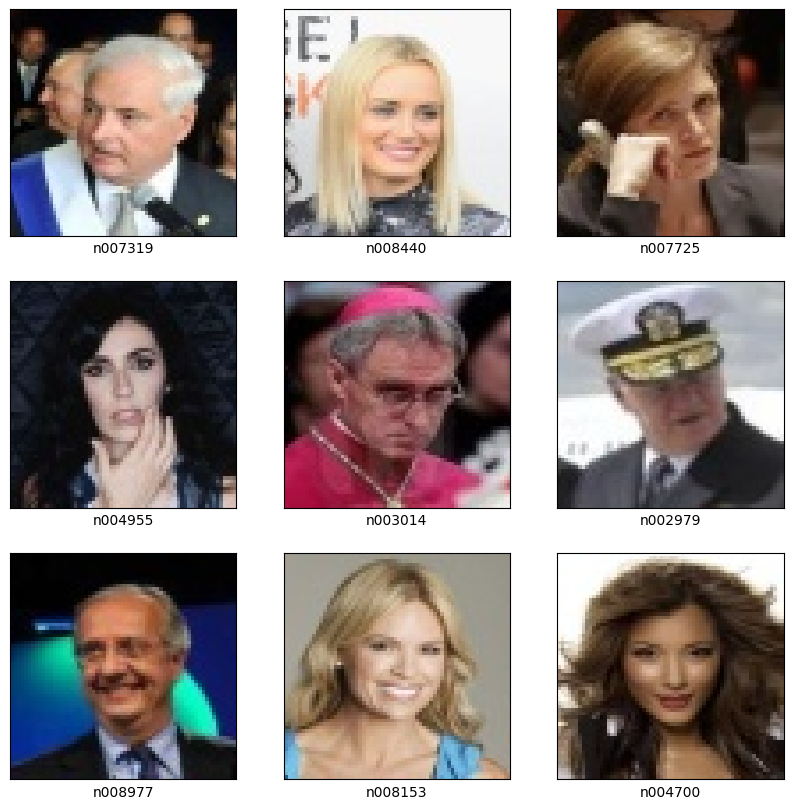

In [7]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.xlabel(label_encoder.inverse_transform([labels[i].numpy()])[0])

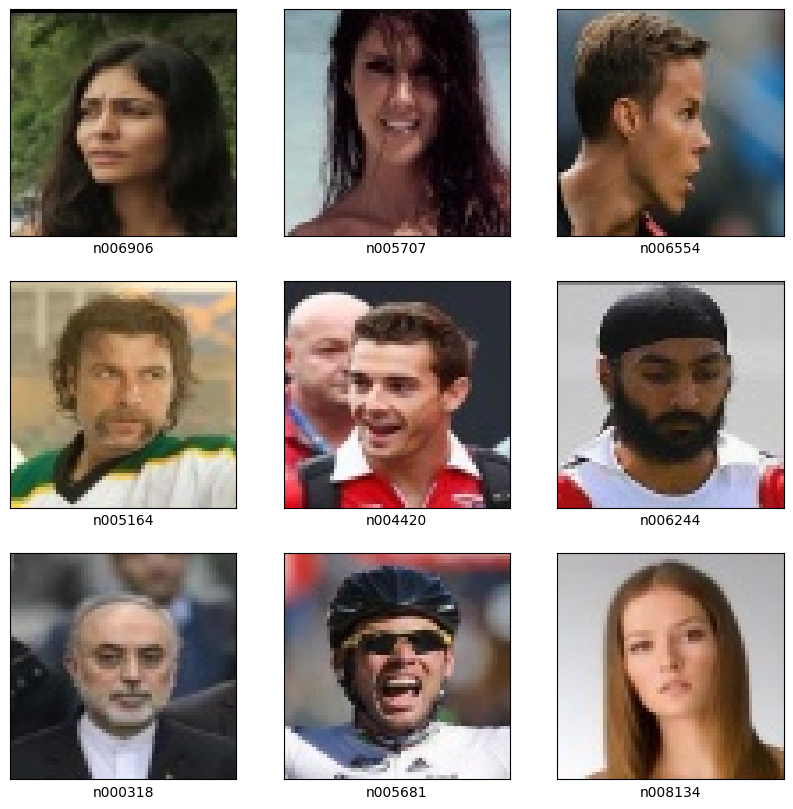

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in test_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.xlabel(label_encoder.inverse_transform([labels[i].numpy()])[0])

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
])

In [10]:
base_model = tf.keras.Sequential([
    
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2), strides=(2,2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2), strides=(2,2)),

    layers.ZeroPadding2D((1,1)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.ZeroPadding2D((1,1)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.SpatialDropout2D(0.2),

    layers.ZeroPadding2D((1,1)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.ZeroPadding2D((1,1)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.SpatialDropout2D(0.2)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
inputs = tf.keras.Input(shape=IMAGE_SHAPE)
x = data_augmentation(inputs)
x = layers.Rescaling(1./255.)(inputs)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 13, 13, 256)    │     1,176,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4000)           │     1,028,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,888 (8.66 MB)

 Trainable params: 2,267,968 (8.65 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
%%time
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights = True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/kaggle/working/classification_weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

EPOCHS = 35

history = model.fit(train_dataset,
                   epochs=EPOCHS,
                   validation_data=val_dataset,
                   callbacks=[early_stop, checkpoint])

Epoch 1/35


I0000 00:00:1753553120.140012      58 service.cc:148] XLA service 0x7e89bc0080f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753553120.141176      58 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1753553120.991953      58 cuda_dnn.cc:529] Loaded cuDNN version 90300


   7/5948 ━━━━━━━━━━━━━━━━━━━━ 1:54 19ms/step - accuracy: 0.0000e+00 - loss: 8.2953

I0000 00:00:1753553128.062334      58 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5948/5948 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0034 - loss: 7.6992
Epoch 1: val_accuracy improved from -inf to 0.02450, saving model to /kaggle/working/classification_weights.h5
5948/5948 ━━━━━━━━━━━━━━━━━━━━ 135s 19ms/step - accuracy: 0.0034 - loss: 7.6991 - val_accuracy: 0.0245 - val_loss: 6.3100
Epoch 2/35
5947/5948 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0423 - loss: 5.9013
Epoch 2: val_accuracy improved from 0.02450 to 0.09763, saving model to /kaggle/working/classification_weights.h5
5948/5948 ━━━━━━━━━━━━━━━━━━━━ 109s 18ms/step - accuracy: 0.0423 - loss: 5.9012 - val_accuracy: 0.0976 - val_loss: 5.1119
Epoch 3/35
5947/5948 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1167 - loss: 4.8869
Epoch 3: val_accuracy improved from 0.09763 to 0.18462, saving model to /kaggle/working/classification_weights.h5
5948/5948 ━━━━━━━━━━━━━━━━━━━━ 109s 18ms/step - accuracy: 0.1167 - loss: 4.8869 - val_accuracy: 0.1846 - val_loss: 4.4240
Epoch 4/35
5947/5948 ━━━━━━━━━━━━━━━━━━

Text(0.5, 1.0, 'Training and Validation Loss')

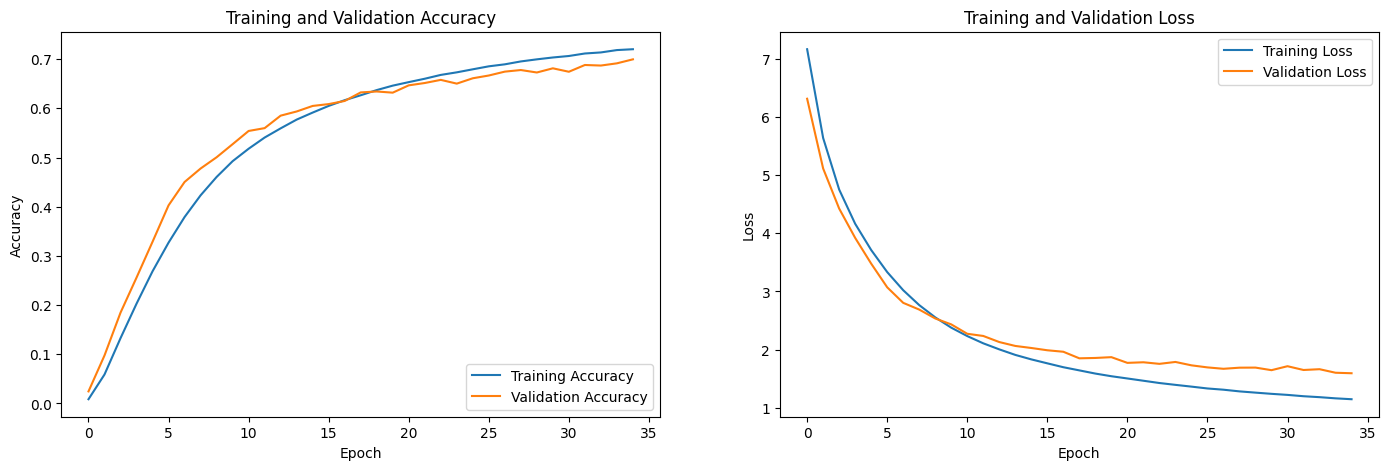

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

In [15]:
loss, accuracy= model.evaluate(test_dataset)
print('Loss:', loss)
print('Accuracy:', accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6966 - loss: 1.5258
Loss: 1.563814401626587
Accuracy: 0.6965000033378601
